# Comparison with ATLAS ITk Events

In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "SuperTrackML"

from utils import get_hist_data, load_config_data, load_single_process

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Points of comparison**
For each combination of config (pileup, pre-cut pt, pre-cut eta, with neutrals, with secondaries):
- Number of hits in each event
- Number of target hits, background hits and noise hits in each event
- Distribution of hit positions in r, z, phi, eta
- Distribution of particle pt
- Distribution of particle eta

## Producing the config combinations

In [3]:
base_config = {
    "events": 3,
    "pythia": True,
    "geant4": True,
    "hard_process": "Top:qqbar2ttbar",
    "pileup": 200,
    "output_csv": False,
    "reco": False,

    "g4_post_pt": 300,
    "g4_post_eta": [-4.0, 4.0],
}

# Define the parameter space
config_options = {
    "g4_pre_pt": [50, 100, 150, 200],
    "g4_pre_eta": [[-4.0, 4.0], [-3.0, 3.0]],
    "g4_record_neutrals": [True, False],
    "g4_record_secondaries": [True, False]
}


In [4]:
def generate_config_name(config):
    """Generate a standardized config name from parameters"""
    return f"config_pt{config['g4_pre_pt']}_eta{config['g4_pre_eta'][0]}_{config['g4_pre_eta'][1]}_neutrals{config['g4_record_neutrals']}_secondaries{config['g4_record_secondaries']}"

def generate_configs(base_config = base_config, config_options = config_options):
    
    # Generate all combinations
    keys, values = zip(*config_options.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    configs = []
    for combo in combinations:
        # Start with base config
        config = base_config.copy()
        # Update with specific combination
        config.update(combo)
        # Generate unique name and output directory
        name = generate_config_name(combo)
        config['output'] = f"outputs/itk_comparison/odd_output_{name}"
        configs.append((name, config))
    
    return configs

In [5]:
# Generate and save configs
output_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/supertrackml/configs/itk_comparison")
output_dir.mkdir(exist_ok=True, parents=True)

configs = generate_configs(base_config = base_config, config_options = config_options)
for name, config in configs:
    with open(output_dir / f"{name}.yaml", 'w') as f:
        yaml.dump(config, f)

## Submit Simulations

In [313]:
# Submit batch jobs
import subprocess

def submit_job(config_path):
    cmd = [
        "sbatch",
        "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/supertrackml/batch/run_acts_parallel.sh",
        str(config_path)
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        job_id = result.stdout.strip().split()[-1]
        return job_id
    else:
        print(f"Error submitting {config_path}: {result.stderr}")
        return None


In [315]:
# Submit all jobs
job_ids = []
for name, _ in configs:
    config_path = output_dir / f"{name}.yaml"
    job_id = submit_job(config_path)
    if job_id:
        job_ids.append(job_id)
        print(f"Submitted {name} as job {job_id}")

print(f"Submitted {len(job_ids)} jobs")

Submitted config_pt50_eta-4.0_4.0_neutralsTrue_secondariesTrue as job 33120442
Submitted config_pt50_eta-4.0_4.0_neutralsTrue_secondariesFalse as job 33120444
Submitted config_pt50_eta-4.0_4.0_neutralsFalse_secondariesTrue as job 33120446
Submitted config_pt50_eta-4.0_4.0_neutralsFalse_secondariesFalse as job 33120448
Submitted config_pt50_eta-3.0_3.0_neutralsTrue_secondariesTrue as job 33120450
Submitted config_pt50_eta-3.0_3.0_neutralsTrue_secondariesFalse as job 33120452
Submitted config_pt50_eta-3.0_3.0_neutralsFalse_secondariesTrue as job 33120454
Submitted config_pt50_eta-3.0_3.0_neutralsFalse_secondariesFalse as job 33120456
Submitted config_pt100_eta-4.0_4.0_neutralsTrue_secondariesTrue as job 33120458
Submitted config_pt100_eta-4.0_4.0_neutralsTrue_secondariesFalse as job 33120461
Submitted config_pt100_eta-4.0_4.0_neutralsFalse_secondariesTrue as job 33120462
Submitted config_pt100_eta-4.0_4.0_neutralsFalse_secondariesFalse as job 33120464
Submitted config_pt100_eta-3.0_3.0_n

In [316]:
# Check job status
for job_id in job_ids:
    cmd = ["squeue", "-j", job_id]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          33120442 regular_m acts_gen danieltm PD       0:00      1 (Priority)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          33120444 regular_m acts_gen danieltm PD       0:00      1 (Priority)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          33120446 regular_m acts_gen danieltm PD       0:00      1 (Priority)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          33120448 regular_m acts_gen danieltm PD       0:00      1 (Priority)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          33120450 regular_m acts_gen danieltm PD       0:00      1 (Priority)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          33120452 regular_m acts_gen danieltm PD       0:00      1 (Priority)

          

## ACTS Explore - single config

In [91]:
all_files

['/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1_ptcut100MeV_withneutral/pythia8_vertices.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1_ptcut100MeV_withneutral/hits.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1_ptcut100MeV_withneutral/measurements.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1_ptcut100MeV_withneutral/pythia8_particles.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1_ptcut100MeV_withneutral/particles_simulation.root']

In [333]:
# acts_directory = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/multi_process_testing/proc_0"
acts_directory = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison/odd_output_config_pt150_eta-4.0_4.0_neutralsTrue_secondariesTrue/proc_31/"
# acts_directory = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/odd_output_geant_ttbar_1"

In [334]:
# Uproot load 
hits_file = f"{acts_directory}/hits.root"
hits_tree = uproot.open(hits_file)

# Get the first entry in the tree
print(hits_tree.keys()) # ['hits;7', 'hits;6']

# Get the keys and sort them by cycle number
keys = hits_tree.keys()
cycles = [int(key.split(';')[1]) for key in keys]
latest_key = keys[cycles.index(max(cycles))]

# Get the hits data
hits_data_1 = hits_tree[latest_key].arrays()

print(f"Lengths: {len(hits_data_1)}")
print(f"Example of {latest_key}: {hits_data_1[0]}")

['hits;3', 'hits;2']
Lengths: 1850896
Example of hits;3: {event_id: 0, geometry_id: 1152921779484754177, particle_id: ..., ...}


In [335]:
particles_file = f"{acts_directory}/particles_simulation.root"
particles_tree = uproot.open(particles_file)

print(particles_tree.keys())

# Get the keys and sort them by cycle number
keys = particles_tree.keys()
cycles = [int(key.split(';')[1]) for key in keys]
latest_key = keys[cycles.index(max(cycles))]
particles_data_1 = particles_tree[latest_key].arrays()

print(f"Lengths: {len(particles_data_1)}")
print(f"Example of {latest_key}: {particles_data_1[0]}")

particles_data_1 = ak.to_dataframe(particles_data_1)
particles_data_1 = particles_data_1.reset_index()
particles_data_1 = particles_data_1.drop(columns=["entry", "subentry"])

particles_data_1


['particles;1']
Lengths: 3
Example of particles;1: {event_id: 0, particle_id: [4503599644147712, ...], particle_type: [...], ...}


,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_primary,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome
0,0,4503599644147712,22,0,-0.001472,-0.008207,64.809265,-1168.866211,-2.256225,5.761503,...,1,0,1,0,0,-8.881784e-16,0.0,0.0,13,2
1,0,4503599660924928,11,0,-0.001472,-0.008207,64.809265,-1168.866211,5.833200,20.807375,...,1,0,2,0,0,1.071284e+01,0.0,0.0,14,2
2,0,4503599660990480,22,0,214.830887,802.646790,569.756775,-196.543457,0.076186,0.298688,...,1,0,2,1,16,0.000000e+00,0.0,0.0,3,2
3,0,4503599761588224,211,0,-0.001472,-0.008207,64.809265,-1168.866211,0.366948,0.045169,...,1,0,8,0,0,3.546581e-01,0.0,0.0,21,1
4,0,4503599811919872,211,0,-0.001472,-0.008207,64.809265,-1168.866211,-0.815121,-0.072302,...,1,0,11,0,0,2.649672e+00,0.0,0.0,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33216,2,905231223763304449,-11,0,1.098631,-138.033417,-882.848145,-1545.375732,0.008153,-1.030256,...,201,7,124,1,1,7.078603e+00,0.0,0.0,1,1
33217,2,905231223763435525,11,0,0.143584,-205.876831,-1344.282959,-1078.978149,-0.027393,-0.656497,...,201,7,124,3,5,4.552318e+00,0.0,0.0,5,1
33218,2,905231223763501100,22,0,0.110755,-206.832565,-1350.838379,-1072.353394,-0.012798,-0.432548,...,201,7,124,4,44,3.005279e+00,0.0,0.0,4,1
33219,2,905235622329843712,-211,0,0.065175,-6.833753,-127.400375,-2310.789551,0.062640,-0.824775,...,201,11,155,0,0,1.516123e-01,0.0,0.0,5,2


In [336]:
pythia_file = f"{acts_directory}/pythia8_particles.root"
pythia_tree = uproot.open(pythia_file)

print(pythia_tree.keys())
pythia_data_1 = pythia_tree['particles;1'].arrays()

print(f"Lengths: {len(pythia_data_1)}")
print(f"Example of pythia;1: {pythia_data_1[0]}")

# This gives a multi index. Flatten that
pythia_data_1 = ak.to_dataframe(pythia_data_1)
pythia_data_1 = pythia_data_1.reset_index()
# Remove the "entry" and "subentry" columns
pythia_data_1 = pythia_data_1.drop(columns=["entry", "subentry"])

pythia_data_1

['particles;1']
Lengths: 3
Example of pythia;1: {event_id: 0, particle_id: [4503599644147712, ...], particle_type: [...], ...}


,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
0,0,4503599644147712,22,0,-0.001472,-0.008207,64.809265,-1168.866211,-2.256225,5.761503,...,0.0,0.176307,1.944044,6.187525,6.283941,1,0,1,0,0
1,0,4503599660924928,11,0,-0.001472,-0.008207,64.809265,-1168.866211,5.833200,20.807375,...,-1.0,0.575327,1.297470,21.609560,25.285698,1,0,2,0,0
2,0,4503599677702144,22,0,-0.001472,-0.008207,64.809265,-1168.866211,0.000193,0.000359,...,0.0,0.802196,1.076278,0.000407,0.000546,1,0,3,0,0
3,0,4503599694479360,2112,0,-0.001472,-0.008207,64.809265,-1168.866211,0.998847,-2.077187,...,0.0,6.863439,-1.122573,2.304864,1102.476440,1,0,4,0,0
4,0,4503599711256576,-211,0,-0.001472,-0.008207,64.809265,-1168.866211,-0.175816,0.031901,...,-1.0,3.640397,2.962098,0.178687,3.406947,1,0,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96181,2,905251016482488320,22,0,0.634779,-3.208290,4730.499023,2181.635742,-0.046041,0.001592,...,0.0,6.623922,3.107038,0.046069,17.342365,201,25,214,0,0
96182,2,905252116010893312,22,0,3.079534,1.852453,61.891445,-2484.959473,0.071948,0.012039,...,0.0,1.092761,0.165796,0.072948,0.121014,201,26,215,0,0
96183,2,905252116027670528,22,0,3.079534,1.852453,61.891445,-2484.959473,0.206675,0.229170,...,0.0,0.489163,0.836964,0.308599,0.346262,201,26,216,0,0
96184,2,905252116044447744,22,0,3.079529,1.852445,61.891457,-2484.959473,0.018461,-0.073819,...,0.0,1.692737,-1.325736,0.076092,0.213756,201,26,217,0,0


In [339]:
# Example usage:
config_name = "config_pt200_eta-3.0_3.0_neutralsFalse_secondariesFalse"
base_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison")
hits_df, particles_df, pythia_df = load_config_data(base_dir, config_name)

if hits_df is not None:
    print(f"Total hits: {len(hits_df)}")
    print(f"Total particles: {len(particles_df)}")

Total hits: 7088484
Total particles: 408382


In [142]:
# Example usage:
config_name = "multi_process_testing"
base_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/")
hits_df, particles_df, pythia_df = load_config_data(base_dir, config_name, num_processes=32, events_per_process=3)

if hits_df is not None:
    print(f"Total hits: {len(hits_df)}")
    print(f"Total particles: {len(particles_df)}")
    print(f"Total pythia: {len(pythia_df)}")

Total hits: 6325280
Total particles: 275744
Total pythia: 994656


### Visualisation

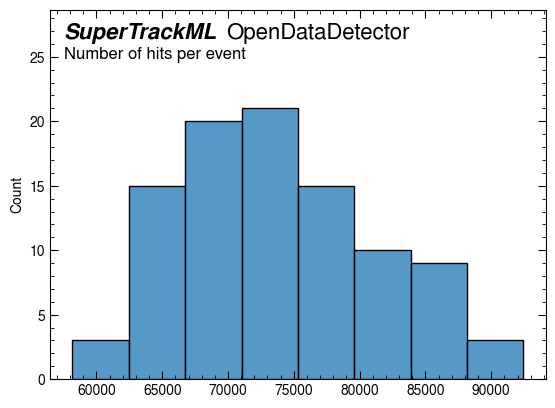

In [340]:
# num hits
num_hits = hits_df.groupby("event_id").size()

sns.histplot(num_hits)
atl.atlasify("OpenDataDetector", "Number of hits per event")
plt.show()

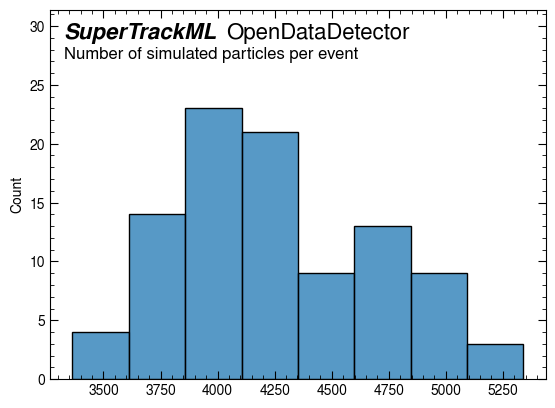

In [341]:
# num simulated particles
num_particles = particles_df.groupby("event_id").size()

sns.histplot(num_particles)
atl.atlasify("OpenDataDetector", "Number of simulated particles per event")
plt.show()

In [343]:
# combined pt
particles_pt = np.sqrt(particles_df["px"]**2 + particles_df["py"]**2)
pythia_pt = np.sqrt(pythia_df["px"]**2 + pythia_df["py"]**2)

target_pythia_df = pythia_df[(pythia_df.vertex_secondary == 0) & (pythia_df.q != 0)]
target_particles_df = particles_df[(particles_df.vertex_secondary == 0) & (particles_df.q != 0)]

target_pythia_pt = np.sqrt(target_pythia_df["px"]**2 + target_pythia_df["py"]**2)
target_particles_pt = np.sqrt(target_particles_df["px"]**2 + target_particles_df["py"]**2)

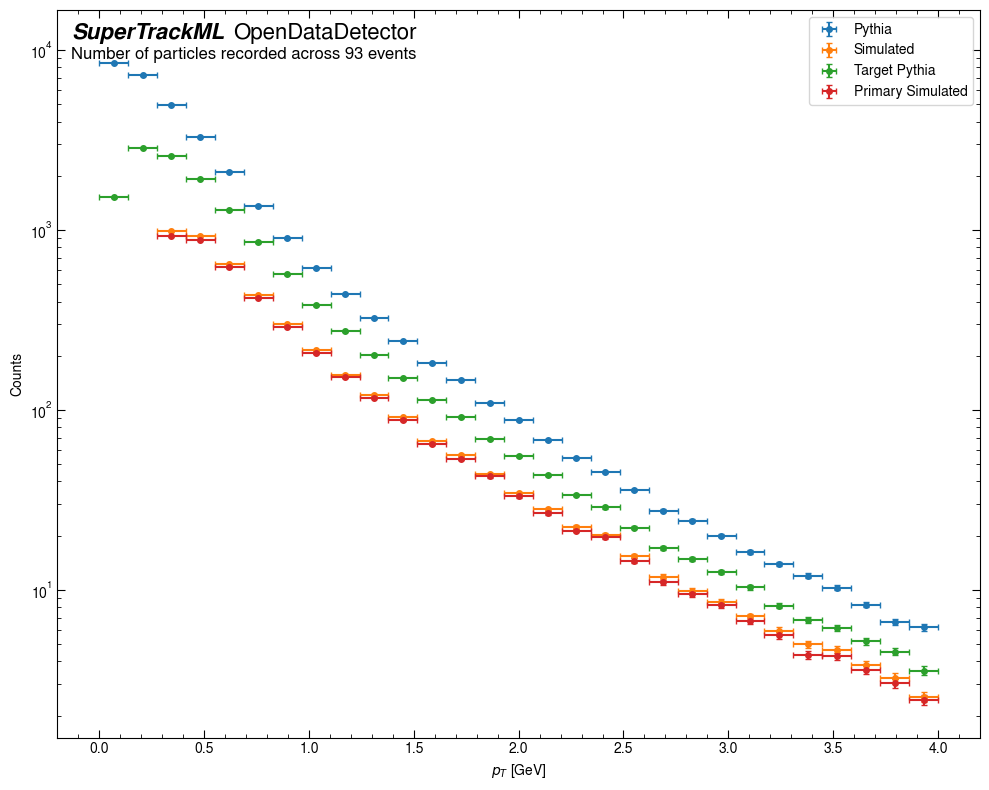

In [344]:
# Define bins
bins = np.linspace(0, 4, 30)

# Get histogram data for each distribution
pythia_centers, pythia_counts, pythia_widths, pythia_errors = get_hist_data(pythia_pt, bins, pythia_df.event_id)
particles_centers, particles_counts, particles_widths, particles_errors = get_hist_data(particles_pt, bins, particles_df.event_id)
target_pythia_centers, target_pythia_counts, target_pythia_widths, target_pythia_errors = get_hist_data(target_pythia_pt, bins, target_pythia_df.event_id)
target_particles_centers, target_particles_counts, target_particles_widths, target_particles_errors = get_hist_data(target_particles_pt, bins, target_particles_df.event_id)

# Create plot
plt.figure(figsize=(10, 8))

# Plot each distribution with error bars
plt.errorbar(pythia_centers, pythia_counts, yerr=pythia_errors, xerr=pythia_widths, 
            fmt='o', label='Pythia', markersize=4, capsize=2)
plt.errorbar(particles_centers, particles_counts, yerr=particles_errors, xerr=particles_widths, 
            fmt='o', label='Simulated', markersize=4, capsize=2)
plt.errorbar(target_pythia_centers, target_pythia_counts, yerr=target_pythia_errors, xerr=target_pythia_widths, 
            fmt='o', label='Target Pythia', markersize=4, capsize=2)
plt.errorbar(target_particles_centers, target_particles_counts, yerr=target_particles_errors, xerr=target_particles_widths, 
            fmt='o', label='Primary Simulated', markersize=4, capsize=2)

plt.xlabel('$p_T$ [GeV]')
plt.ylabel('Counts')
plt.yscale('log')  # Optional: use log scale if the distributions vary widely

# Apply ATLAS style
atl.atlasify("OpenDataDetector", "Number of particles recorded across 93 events")

plt.legend()
plt.tight_layout()
plt.show()

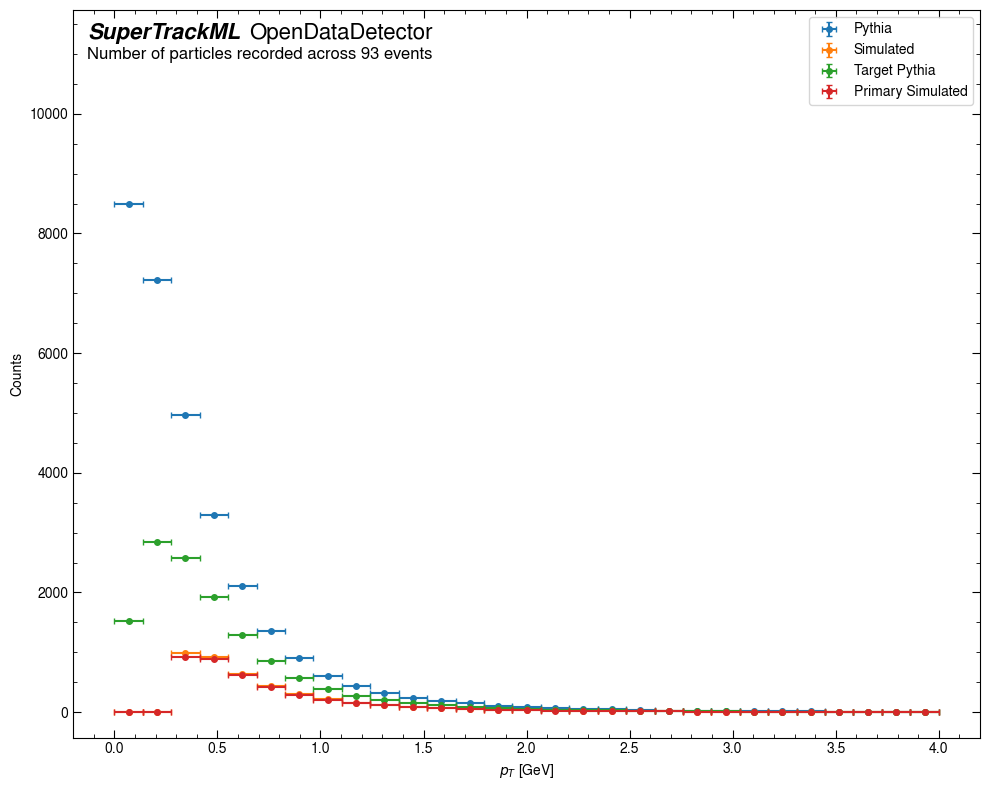

In [345]:
# Define bins
bins = np.linspace(0, 4, 30)

# Get histogram data for each distribution
pythia_centers, pythia_counts, pythia_widths, pythia_errors = get_hist_data(pythia_pt, bins, pythia_df.event_id)
particles_centers, particles_counts, particles_widths, particles_errors = get_hist_data(particles_pt, bins, particles_df.event_id)
target_pythia_centers, target_pythia_counts, target_pythia_widths, target_pythia_errors = get_hist_data(target_pythia_pt, bins, target_pythia_df.event_id)
target_particles_centers, target_particles_counts, target_particles_widths, target_particles_errors = get_hist_data(target_particles_pt, bins, target_particles_df.event_id)

# Create plot
plt.figure(figsize=(10, 8))

# Plot each distribution with error bars
plt.errorbar(pythia_centers, pythia_counts, yerr=pythia_errors, xerr=pythia_widths, 
            fmt='o', label='Pythia', markersize=4, capsize=2)
plt.errorbar(particles_centers, particles_counts, yerr=particles_errors, xerr=particles_widths, 
            fmt='o', label='Simulated', markersize=4, capsize=2)
plt.errorbar(target_pythia_centers, target_pythia_counts, yerr=target_pythia_errors, xerr=target_pythia_widths, 
            fmt='o', label='Target Pythia', markersize=4, capsize=2)
plt.errorbar(target_particles_centers, target_particles_counts, yerr=target_particles_errors, xerr=target_particles_widths, 
            fmt='o', label='Primary Simulated', markersize=4, capsize=2)

plt.xlabel('$p_T$ [GeV]')
plt.ylabel('Counts')

# Apply ATLAS style
atl.atlasify("OpenDataDetector", "Number of particles recorded across 93 events")

plt.legend()
plt.tight_layout()
plt.show()

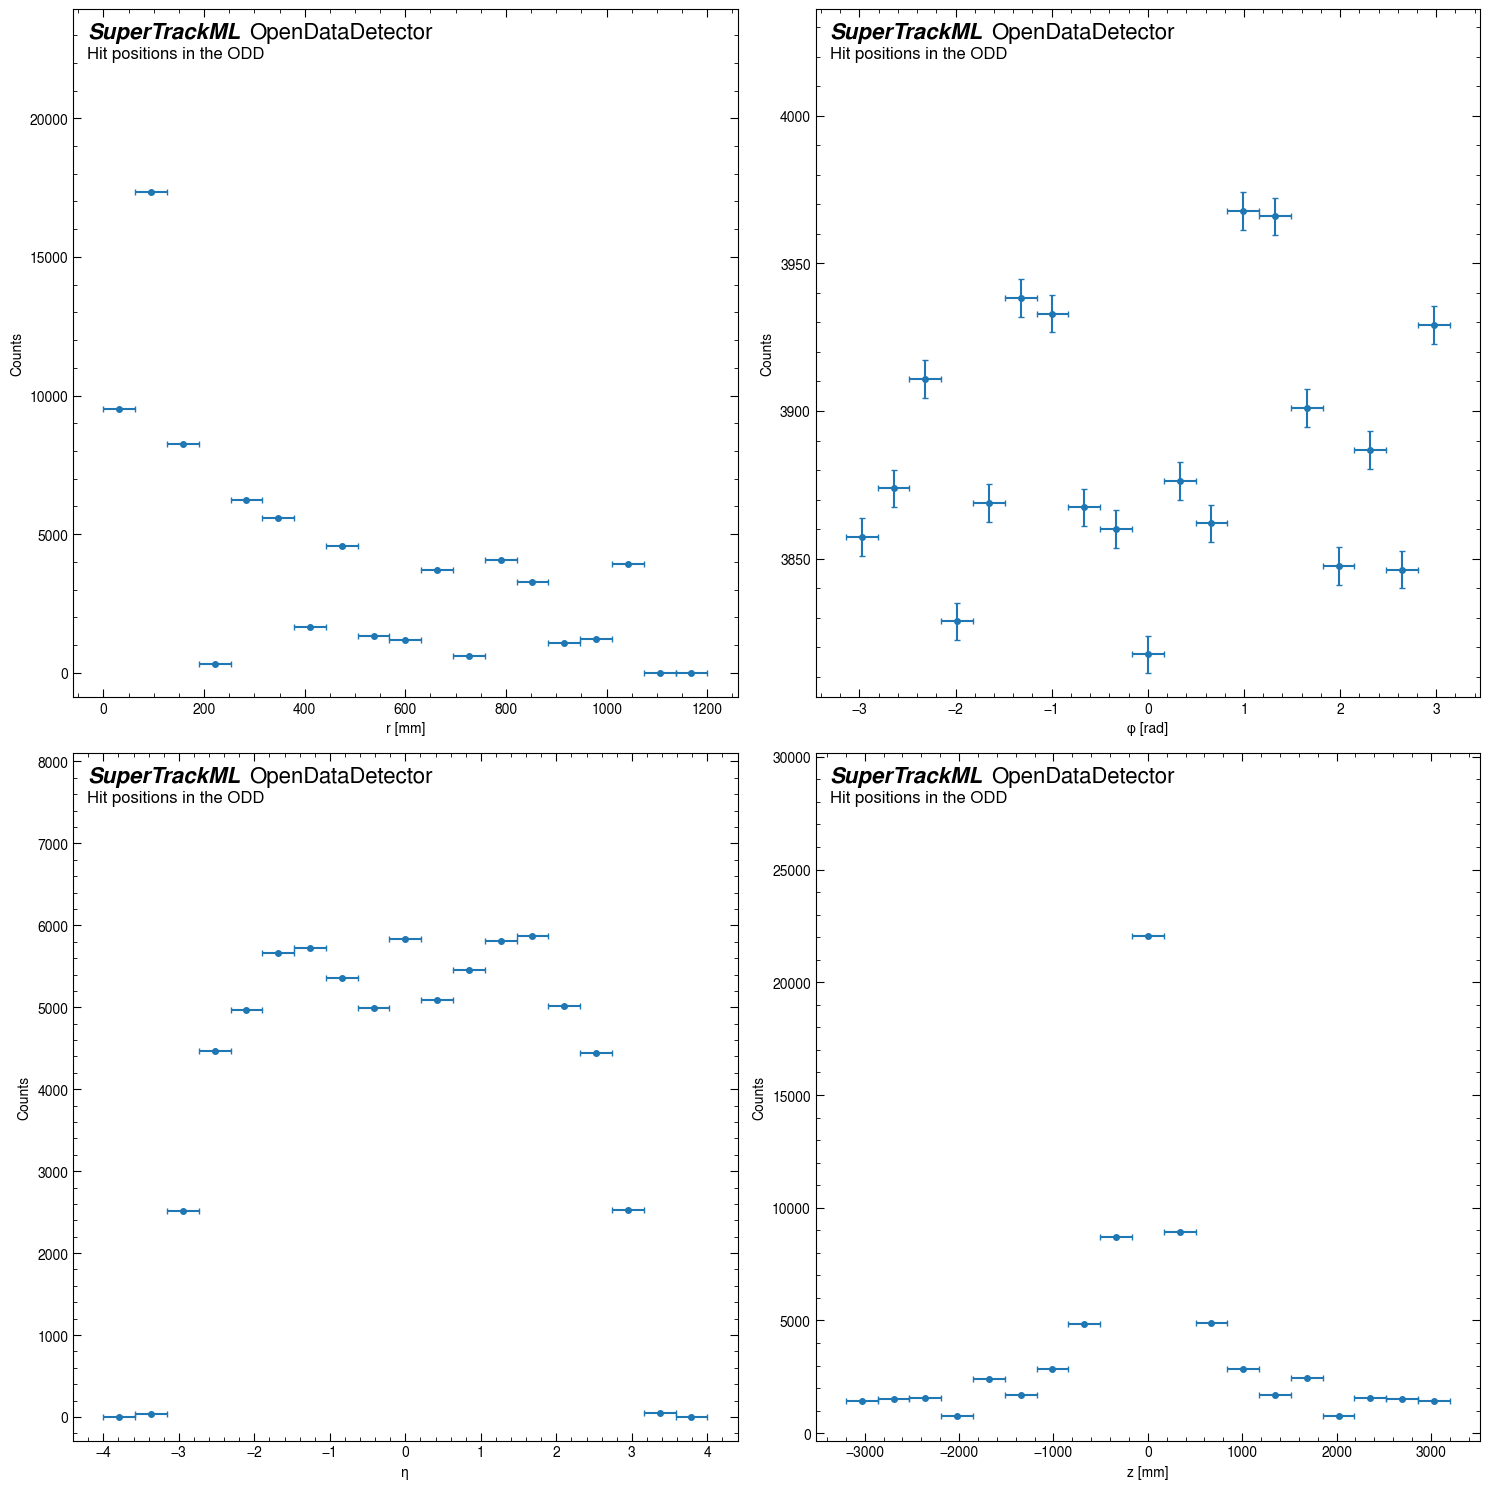

In [346]:
# First check the intermediate values
hits_df["r"] = np.sqrt(hits_df.tx**2 + hits_df.ty**2)
hits_df["phi"] = np.arctan2(hits_df.ty, hits_df.tx)

# Modified theta calculation to handle edge cases
hits_df["theta"] = np.arctan2(np.sqrt(hits_df.tx**2 + hits_df.ty**2), hits_df.tz)

# More robust eta calculation
hits_df["eta"] = -np.log(np.tan(hits_df.theta/2 + 1e-10))  # Add small epsilon to avoid exact 0/π

r_centers, r_counts, r_widths, r_errors = get_hist_data(hits_df.r, np.linspace(0, 1200, 20), hits_df.event_id)
phi_centers, phi_counts, phi_widths, phi_errors = get_hist_data(hits_df.phi, np.linspace(-np.pi, np.pi, 20), hits_df.event_id)
eta_centers, eta_counts, eta_widths, eta_errors = get_hist_data(hits_df.eta, np.linspace(-4, 4, 20), hits_df.event_id)
z_centers, z_counts, z_widths, z_errors = get_hist_data(hits_df.tz, np.linspace(-3200, 3200, 20), hits_df.event_id)

fig, axs = plt.subplots(2, 2, figsize=(15, 15))
axs[0, 0].errorbar(r_centers, r_counts, yerr=r_errors, xerr=r_widths, 
            fmt='o', label='r', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[0, 0])
axs[0, 0].set_xlabel("r [mm]")
axs[0, 0].set_ylabel("Counts")

axs[0, 1].errorbar(phi_centers, phi_counts, yerr=phi_errors, xerr=phi_widths, 
            fmt='o', label='phi', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[0, 1])
axs[0, 1].set_xlabel("φ [rad]")
axs[0, 1].set_ylabel("Counts")

axs[1, 0].errorbar(eta_centers, eta_counts, yerr=eta_errors, xerr=eta_widths, 
            fmt='o', label='eta', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[1, 0])
axs[1, 0].set_xlabel("η")
axs[1, 0].set_ylabel("Counts")

axs[1, 1].errorbar(z_centers, z_counts, yerr=z_errors, xerr=z_widths, 
            fmt='o', label='z', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[1, 1])
axs[1, 1].set_xlabel("z [mm]")
axs[1, 1].set_ylabel("Counts")

plt.tight_layout()
plt.show()



In [347]:
# Calculate d0
d0 = np.sqrt(particles_df.vx**2 + particles_df.vy**2)

# Create masks for each condition
target_mask = (
    (particles_df.vertex_secondary == 0) &
    (particles_df.q != 0) &
    (particles_df.pt > 1) &
    (d0 < 0.26)
)

background_mask = (
    (particles_df.q != 0) &
    (particles_df.pt < 1)
)

# Apply masks to get different particle categories
target_particles_df = particles_df[target_mask]
background_particles_df = particles_df[background_mask & ~target_mask]  # Ensure no overlap with target
noise_particles_df = particles_df[~target_mask & ~background_mask]  # Everything else

# Calculate statistics
n_events = len(particles_df.event_id.unique())
print(f"Target particles per event: {len(target_particles_df) / n_events:.2f}")
print(f"Background particles per event: {len(background_particles_df) / n_events:.2f}")
print(f"Noise particles per event: {len(noise_particles_df) / n_events:.2f}")

Target particles per event: 860.50
Background particles per event: 3352.42
Noise particles per event: 41.06


In [348]:
# Merge hits to target particles on both particle_id and event_id
target_hits = hits_df.merge(target_particles_df, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
background_hits = hits_df.merge(background_particles_df, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
# Noise hits should be all hits not associated with target or background particles
noise_hits = hits_df[~hits_df.index.isin(target_hits.index) & ~hits_df.index.isin(background_hits.index)]

print(f"Total hits per event: {len(hits_df) / n_events:.2f}")
print(f"Target hits per event: {len(target_hits) / n_events:.2f}")
print(f"Background hits per event: {len(background_hits) / n_events:.2f}")
print(f"Noise hits per event: {len(noise_hits) / n_events:.2f}")

Total hits per event: 73838.38
Target hits per event: 11822.21
Background hits per event: 47065.20
Noise hits per event: 26773.18


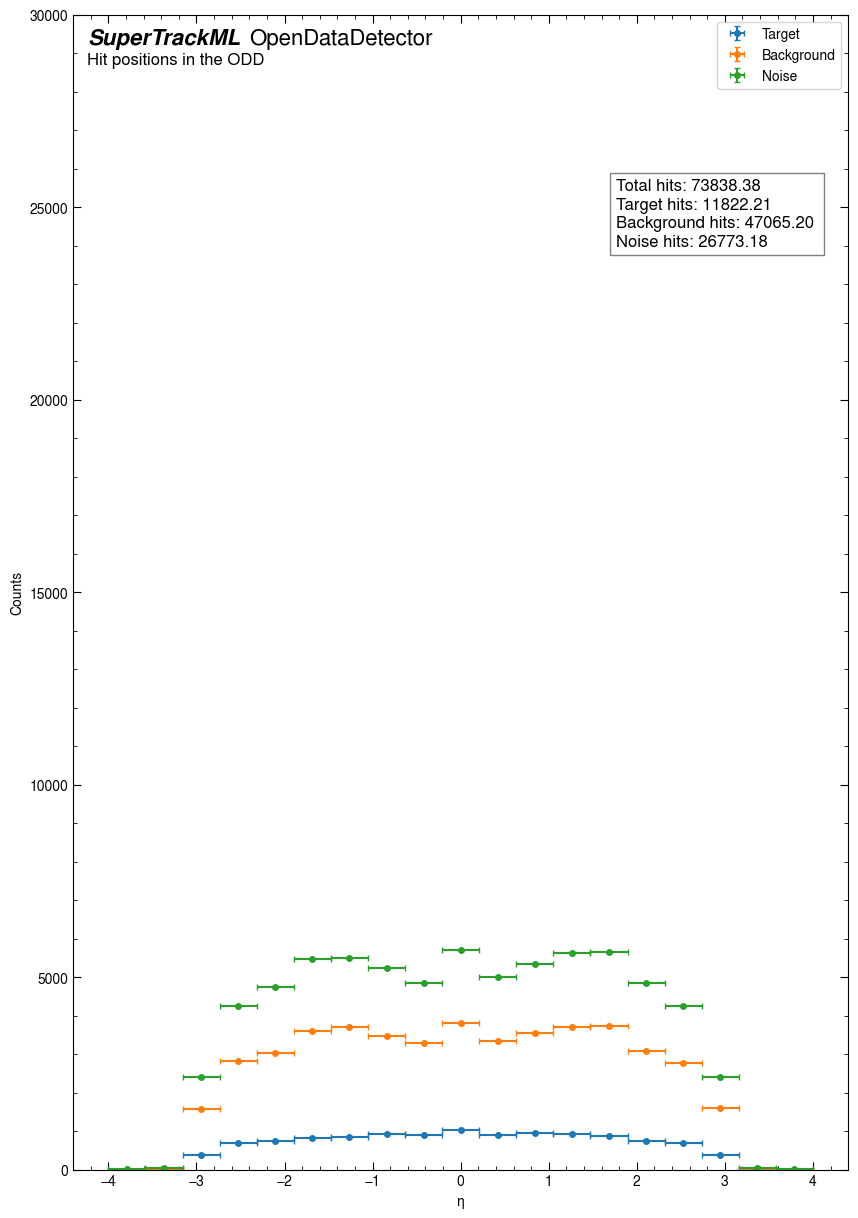

In [350]:
# Plot the counts of each kind of hits in each event, against eta
target_hits_eta_centers, target_hits_eta_counts, target_hits_eta_widths, target_hits_eta_errors = get_hist_data(target_hits.eta, np.linspace(-4, 4, 20), target_hits.event_id)
background_hits_eta_centers, background_hits_eta_counts, background_hits_eta_widths, background_hits_eta_errors = get_hist_data(background_hits.eta, np.linspace(-4, 4, 20), background_hits.event_id)
noise_hits_eta_centers, noise_hits_eta_counts, noise_hits_eta_widths, noise_hits_eta_errors = get_hist_data(noise_hits.eta, np.linspace(-4, 4, 20), noise_hits.event_id)

fig = plt.figure(figsize=(10, 15))
# Plot all in same figure

plt.errorbar(target_hits_eta_centers, target_hits_eta_counts, yerr=target_hits_eta_errors, xerr=target_hits_eta_widths, 
            fmt='o', label='Target', markersize=4, capsize=2)
plt.xlabel("η")
plt.ylabel("Counts")

plt.errorbar(background_hits_eta_centers, background_hits_eta_counts, yerr=background_hits_eta_errors, xerr=background_hits_eta_widths, 
            fmt='o', label='Background', markersize=4, capsize=2)

plt.errorbar(noise_hits_eta_centers, noise_hits_eta_counts, yerr=noise_hits_eta_errors, xerr=noise_hits_eta_widths, 
            fmt='o', label='Noise', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD")

# y scale limits to match itk
plt.ylim(0, 30000)

# Add the totals into the plot, in a box
plt.text(0.7, 0.8, f"Total hits: {len(hits_df)/n_events:.2f} \nTarget hits: {len(target_hits)/n_events:.2f} \nBackground hits: {len(background_hits)/n_events:.2f} \nNoise hits: {len(noise_hits)/n_events:.2f}", transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.legend()

plt.show()

## ITk Explore

In [351]:
itk_directory  = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data/feature_store/valset"
itk_hit_files = sorted(glob.glob(itk_directory + "/*-truth.csv"))
itk_particle_files = sorted(glob.glob(itk_directory + "/*-particles.csv"))


In [352]:
itk_hit_event = pd.read_csv(itk_hit_files[0])
itk_particle_event = pd.read_csv(itk_particle_files[0])

In [353]:
# Load ten events and concatenate
itk_hit_events = []
itk_particle_events = []
for i in range(10):
    itk_hit_event = pd.read_csv(itk_hit_files[i])
    itk_particle_event = pd.read_csv(itk_particle_files[i])

    # Add event_id
    itk_hit_event["event_id"] = i
    itk_particle_event["event_id"] = i

    itk_hit_events.append(itk_hit_event)
    itk_particle_events.append(itk_particle_event)

itk_hits = pd.concat(itk_hit_events).reset_index(drop=True)
itk_particles = pd.concat(itk_particle_events).reset_index(drop=True)

In [286]:
itk_hits

,hit_id,x,y,z,cluster_index_1,cluster_index_2,hardware,cluster_x_1,cluster_y_1,cluster_z_1,...,glob_eta_2,glob_phi_2,eta_angle_2,phi_angle_2,particle_id_2,particle_id,region,module_id,SPisOverlap,event_id
0,0,11.340760,32.499437,-265.000,0,0,PIXEL,11.340759,32.499435,-265.000,...,1.496611,2.181662,1.249046,1.249046,0,0,1.0,26388279066624,-1,0
1,1,0.583162,34.548606,-265.000,1,1,PIXEL,0.583162,34.548607,-265.000,...,1.496611,2.181662,1.249046,1.249046,4270010105,4270010105,1.0,26388279066624,-1,0
2,2,2.333990,34.976072,-265.000,2,2,PIXEL,2.333990,34.976070,-265.000,...,1.103587,2.503412,1.249046,0.982794,6100010199,6100010199,1.0,26388279066624,-1,0
3,3,12.474595,33.314938,-265.000,3,3,PIXEL,12.474595,33.314938,-265.000,...,1.103587,1.859911,0.982794,1.249046,4680010164,4680010164,1.0,26388279066624,-1,0
4,4,-1.324370,36.255781,-265.000,4,4,PIXEL,-1.324370,36.255783,-265.000,...,1.103587,1.859911,0.982794,1.249046,4330010123,4330010123,1.0,26388279066624,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719045,397870,885.300591,-175.800223,2854.285,551952,552064,STRIP,870.606450,-172.559890,2854.285,...,0.007968,1.419433,1.337319,0.007968,0,0,6.0,963568010117775360,2,9
3719046,397871,667.318280,-68.570296,2854.285,551978,537562,STRIP,651.326300,-66.583244,2854.285,...,0.009931,1.514674,1.350388,0.009930,0,0,6.0,963702150536364032,2,9
3719047,397872,723.537850,-71.283368,2854.285,552009,537591,STRIP,735.804930,-72.722050,2854.285,...,0.009931,1.514387,1.322975,0.009930,0,0,6.0,963705449071247360,2,9
3719048,397873,803.493532,-75.849270,2854.285,552024,537605,STRIP,780.764950,-73.232750,2854.285,...,0.005862,1.512779,0.955804,0.005862,6480200189,6480200189,6.0,963706548582875136,2,9


In [287]:
itk_particles

,particle_id,subevent,barcode,px,py,pz,pt,eta,vx,vy,...,status,charge,pdgId,pass,vProdNIn,vProdNOut,vProdStatus,vProdBarcode,num_clusters,event_id
0,11500001179,1150,1179,-251840.92000,25411.627000,-107176.69500,253119.73000,-0.411694,0.006758,-0.005379,...,1,-1.0,13,1,1,2,-933,-933,14,0
1,11500001238,1150,1238,-1096.79750,895.249100,-23362.49200,1415.78100,-3.497514,0.006758,-0.005379,...,1,-1.0,-211,1,4,6,-989,-989,13,0
2,11500001248,1150,1248,194.64886,-320.546970,-1212.39000,375.01804,-1.889627,0.006758,-0.005379,...,1,1.0,211,0,6,8,-996,-996,22,0
3,11500001250,1150,1250,288.20148,-383.057920,-1256.91550,479.36777,-1.691621,0.006758,-0.005379,...,1,-1.0,-321,0,6,8,-996,-996,21,0
4,11500001251,1150,1251,1895.60200,-2452.454000,-7207.57900,3099.65140,-1.580315,0.006758,-0.005379,...,1,1.0,211,1,6,8,-996,-996,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190799,6780200033,678,200033,-467.54150,254.438690,557.06280,532.29140,0.913901,10.981250,22.001148,...,20001,1.0,2212,0,1,7,-112,-200037,13,9
190800,6780200035,678,200035,140.43535,-519.890500,758.55700,538.52410,1.142962,86.822030,-256.820620,...,20001,1.0,-11,0,1,1,-114,-200039,8,9
190801,6780200039,678,200039,-392.89783,171.262190,-364.52585,428.60170,-0.771618,-88.973366,59.671360,...,20001,1.0,211,0,1,2,-122,-200047,9,9
190802,6780200040,678,200040,-548.60580,-73.443820,-5152.86700,553.50000,-2.927066,-88.973366,59.671360,...,20001,1.0,2212,0,1,2,-122,-200047,3,9


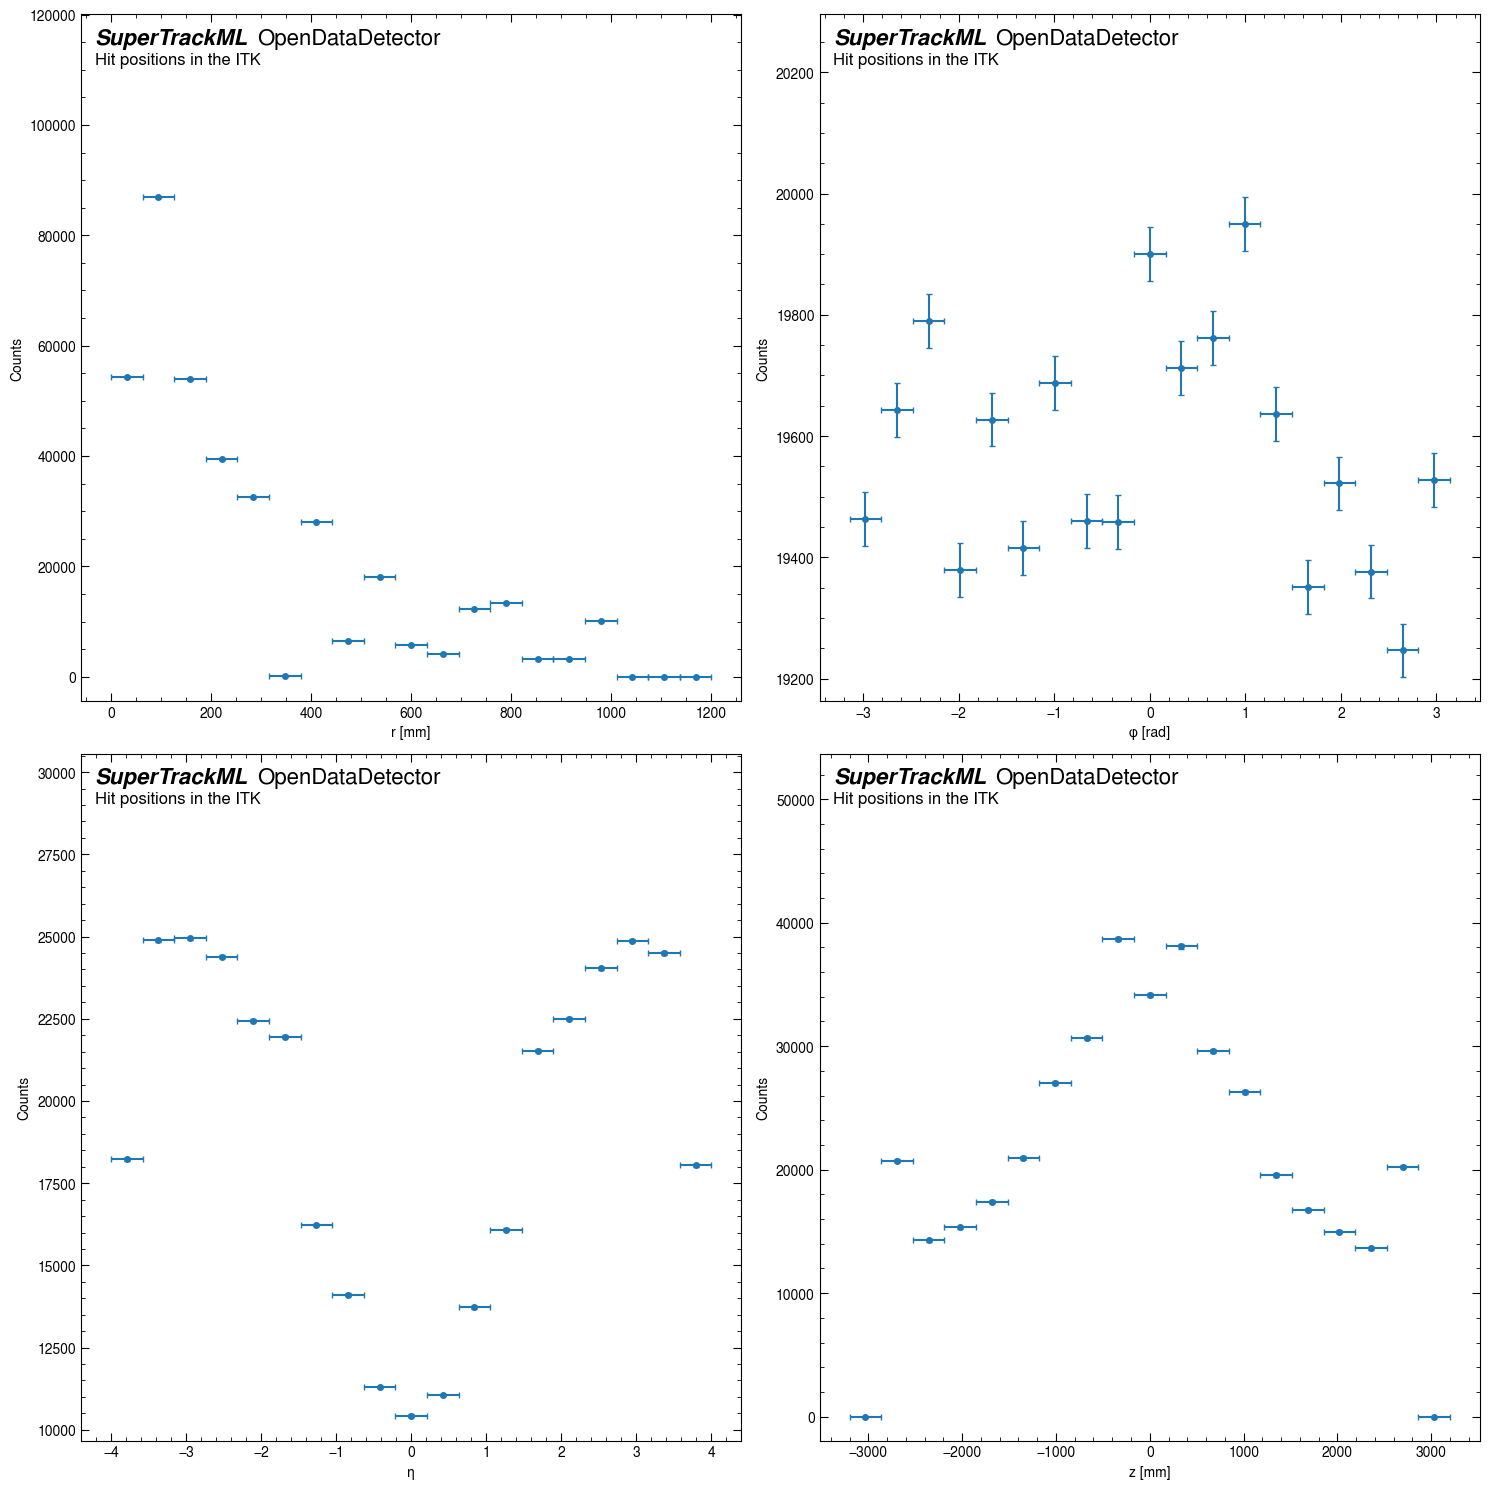

In [354]:
# ITK hits positions
itk_hits["r"] = np.sqrt(itk_hits["x"]**2 + itk_hits["y"]**2)
itk_hits["phi"] = np.arctan2(itk_hits["y"], itk_hits["x"])
itk_hits["theta"] = np.arctan2(np.sqrt(itk_hits["x"]**2 + itk_hits["y"]**2), itk_hits["z"])
itk_hits["eta"] = -np.log(np.tan(itk_hits["theta"]/2 + 1e-10))

itk_r_centers, itk_r_counts, itk_r_widths, itk_r_errors = get_hist_data(itk_hits.r, np.linspace(0, 1200, 20), itk_hits.event_id)
itk_phi_centers, itk_phi_counts, itk_phi_widths, itk_phi_errors = get_hist_data(itk_hits.phi, np.linspace(-np.pi, np.pi, 20), itk_hits.event_id)
itk_eta_centers, itk_eta_counts, itk_eta_widths, itk_eta_errors = get_hist_data(itk_hits.eta, np.linspace(-4, 4, 20), itk_hits.event_id)
itk_z_centers, itk_z_counts, itk_z_widths, itk_z_errors = get_hist_data(itk_hit_event.z, np.linspace(-3200, 3200, 20), itk_hit_event.event_id)

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

axs[0, 0].errorbar(itk_r_centers, itk_r_counts, yerr=itk_r_errors, xerr=itk_r_widths, 
            fmt='o', label='r', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ITK", axes=axs[0, 0])
axs[0, 0].set_xlabel("r [mm]")
axs[0, 0].set_ylabel("Counts")

axs[0, 1].errorbar(itk_phi_centers, itk_phi_counts, yerr=itk_phi_errors, xerr=itk_phi_widths, 
            fmt='o', label='phi', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ITK", axes=axs[0, 1])
axs[0, 1].set_xlabel("φ [rad]")
axs[0, 1].set_ylabel("Counts")

axs[1, 0].errorbar(itk_eta_centers, itk_eta_counts, yerr=itk_eta_errors, xerr=itk_eta_widths, 
            fmt='o', label='eta', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ITK", axes=axs[1, 0])
axs[1, 0].set_xlabel("η")
axs[1, 0].set_ylabel("Counts")

axs[1, 1].errorbar(itk_z_centers, itk_z_counts, yerr=itk_z_errors, xerr=itk_z_widths, 
            fmt='o', label='z', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ITK", axes=axs[1, 1])
axs[1, 1].set_xlabel("z [mm]")
axs[1, 1].set_ylabel("Counts")

plt.tight_layout()
plt.show()


In [355]:
itk_target_mask = (
    (itk_particles["pass"] == 1) &
    (itk_particles.pt > 1000) &
    (itk_particles.radius < 260) &
    (itk_particles.charge != 0)
)
itk_background_mask = (
    (itk_particles.pt < 1000) &
    (itk_particles.charge != 0)
)

itk_target_particles = itk_particles[itk_target_mask]
itk_background_particles = itk_particles[itk_background_mask]
itk_noise_particles = itk_particles[~itk_target_mask & ~itk_background_mask]

itk_target_hits = itk_hits.merge(itk_target_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
itk_background_hits = itk_hits.merge(itk_background_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
itk_noise_hits = itk_hits[~itk_hits.index.isin(itk_target_hits.index) & ~itk_hits.index.isin(itk_background_hits.index)]

print(f"Total particles per event: {len(itk_particles) / len(itk_hit_events):.2f}")
print(f"Target particles per event: {len(itk_target_particles) / len(itk_hit_events):.2f}")
print(f"Background particles per event: {len(itk_background_particles) / len(itk_hit_events):.2f}")
print(f"Noise particles per event: {len(itk_noise_particles) / len(itk_hit_events):.2f}")

print(f"Total hits per event: {len(itk_hits) / len(itk_hit_events):.2f}")
print(f"Target hits per event: {len(itk_target_hits) / len(itk_hit_events):.2f}")
print(f"Background hits per event: {len(itk_background_hits) / len(itk_hit_events):.2f}")
print(f"Noise hits per event: {len(itk_noise_hits) / len(itk_hit_events):.2f}")


Total particles per event: 19080.40
Target particles per event: 1381.30
Background particles per event: 17096.70
Noise particles per event: 602.40
Total hits per event: 371905.00
Target hits per event: 16044.70
Background hits per event: 139524.30
Noise hits per event: 232380.70


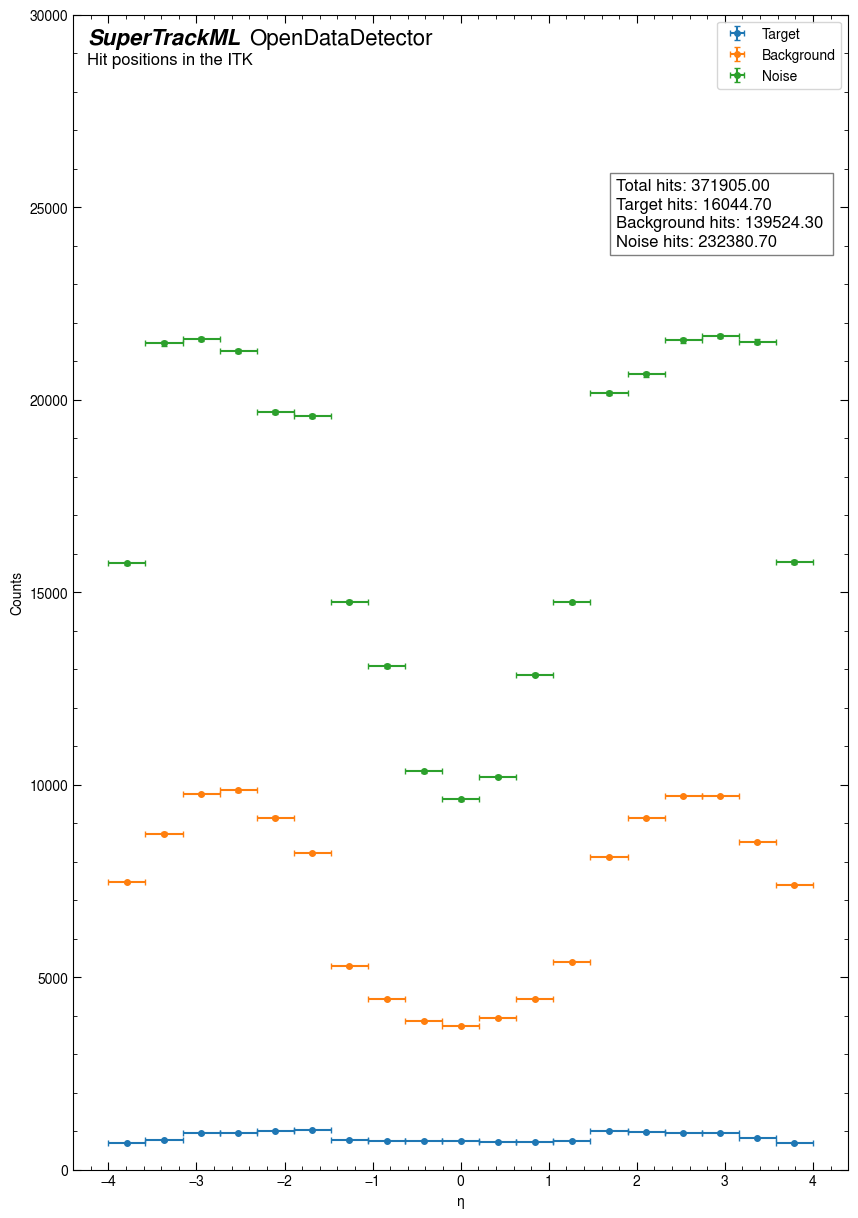

In [358]:
# Plot the counts of each kind of hits in each event, against eta
itk_target_hits_eta_centers, itk_target_hits_eta_counts, itk_target_hits_eta_widths, itk_target_hits_eta_errors = get_hist_data(itk_target_hits.eta, np.linspace(-4, 4, 20), itk_target_hits.event_id)
itk_background_hits_eta_centers, itk_background_hits_eta_counts, itk_background_hits_eta_widths, itk_background_hits_eta_errors = get_hist_data(itk_background_hits.eta, np.linspace(-4, 4, 20), itk_background_hits.event_id)
itk_noise_hits_eta_centers, itk_noise_hits_eta_counts, itk_noise_hits_eta_widths, itk_noise_hits_eta_errors = get_hist_data(itk_noise_hits.eta, np.linspace(-4, 4, 20), itk_noise_hits.event_id)

fig = plt.figure(figsize=(10, 15))

plt.errorbar(itk_target_hits_eta_centers, itk_target_hits_eta_counts, yerr=itk_target_hits_eta_errors, xerr=itk_target_hits_eta_widths, 
            fmt='o', label='Target', markersize=4, capsize=2)
plt.errorbar(itk_background_hits_eta_centers, itk_background_hits_eta_counts, yerr=itk_background_hits_eta_errors, xerr=itk_background_hits_eta_widths, 
            fmt='o', label='Background', markersize=4, capsize=2)
plt.errorbar(itk_noise_hits_eta_centers, itk_noise_hits_eta_counts, yerr=itk_noise_hits_eta_errors, xerr=itk_noise_hits_eta_widths, 
            fmt='o', label='Noise', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ITK")

plt.xlabel("η")
plt.ylabel("Counts")
plt.ylim(0, 30000)

plt.text(0.7, 0.8, f"Total hits: {len(itk_hits) / len(itk_hit_events):.2f} \nTarget hits: {len(itk_target_hits) / len(itk_hit_events):.2f} \nBackground hits: {len(itk_background_hits) / len(itk_hit_events):.2f} \nNoise hits: {len(itk_noise_hits) / len(itk_hit_events):.2f}", transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.legend()

# Save the plot
os.makedirs("comparison_plots/config_itk", exist_ok=True)
plt.savefig("comparison_plots/config_itk/hit_classification.png")



## Comparisons

In [13]:
def calculate_derived_quantities(hits_df):
    """Calculate r, phi, theta, eta from hit positions"""
    hits_df = hits_df.copy()
    hits_df["r"] = np.sqrt(hits_df.tx**2 + hits_df.ty**2)
    hits_df["phi"] = np.arctan2(hits_df.ty, hits_df.tx)
    hits_df["theta"] = np.arctan2(np.sqrt(hits_df.tx**2 + hits_df.ty**2), hits_df.tz)
    hits_df["eta"] = -np.log(np.tan(hits_df.theta/2 + 1e-10))
    return hits_df

def classify_particles(particles_df):
    """Classify particles into target, background, and noise"""
    d0 = np.sqrt(particles_df.vx**2 + particles_df.vy**2)
    
    target_mask = (
        (particles_df.vertex_secondary == 0) &
        (particles_df.q != 0) &
        (particles_df.pt > 1) &
        (d0 < 0.26)
    )
    background_mask = (
        (particles_df.q != 0) &
        (particles_df.pt < 1)
    )
    
    return {
        'target': particles_df[target_mask],
        'background': particles_df[background_mask & ~target_mask],
        'noise': particles_df[~target_mask & ~background_mask]
    }

def classify_hits(hits_df, classified_particles):
    """Match hits to classified particles"""
    hits_by_class = {}
    used_indices = set()
    
    for category, particles in classified_particles.items():
        category_hits = hits_df.merge(
            particles, 
            on=["event_id", "particle_id"], 
            how="inner", 
            suffixes=["", "_particles"]
        )
        used_indices.update(category_hits.index)
        hits_by_class[category] = category_hits
    
    # Remaining hits are noise
    noise_hits = hits_df[~hits_df.index.isin(used_indices)]
    hits_by_class['noise'] = noise_hits
    
    return hits_by_class

def plot_detector_coverage(hits_df, config_name):
    """Create detector coverage plots (r, phi, eta, z)"""
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))
    
    plot_params = [
        (hits_df.r, "r", np.linspace(0, 1200, 20), "[mm]"),
        (hits_df.phi, "φ", np.linspace(-np.pi, np.pi, 20), ""),
        (hits_df.eta, "η", np.linspace(-4, 4, 20), ""),
        (hits_df.tz, "z", np.linspace(-3200, 3200, 20), "[mm]")
    ]
    
    for (data, label, bins, units), ax in zip(plot_params, axs.flat):
        centers, counts, widths, errors = get_hist_data(
            data, bins, hits_df.event_id
        )
        ax.errorbar(centers, counts, yerr=errors, xerr=widths,
                   fmt='o', label=label, markersize=4, capsize=2)
        atl.atlasify("OpenDataDetector", f"Hit positions - {config_name}", axes=ax)
        ax.set_xlabel(f"{label} {units}".strip())
        ax.set_ylabel("Counts")
        
        # Set y-limits based on plot type
        if label == "r":
            ax.set_ylim(0, 2000)
        elif label == "φ":
            ax.set_ylim(0, 1000)
        elif label == "η":
            ax.set_ylim(0, 1500)
        elif label == "z":
            ax.set_ylim(0, 800)
    
    plt.tight_layout()
    return fig

def plot_hit_classification(classified_hits, config_name):
    """Create hit classification plot"""
    fig = plt.figure(figsize=(10, 15))
    
    n_events = len(next(iter(classified_hits.values())).event_id.unique())
    
    for category, hits in classified_hits.items():
        centers, counts, widths, errors = get_hist_data(
            hits.eta, np.linspace(-4, 4, 20), hits.event_id
        )
        plt.errorbar(centers, counts, yerr=errors, xerr=widths,
                    fmt='o', label=category.title(), markersize=4, capsize=2)
    
    # Add statistics text box
    stats_text = "\n".join(
        f"{category.title()} hits: {len(hits)/n_events:.2f}"
        for category, hits in classified_hits.items()
    )
    # Add total hits
    total_hits = sum(len(hits) for hits in classified_hits.values())
    stats_text += f"\nTotal hits: {total_hits/n_events:.2f}"

    plt.text(0.7, 0.8, stats_text,
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.5))
    
    atl.atlasify("OpenDataDetector", f"Hit classification - {config_name}")
    plt.ylim(0, 30000)
    plt.xlabel("η")
    plt.ylabel("Counts")
    plt.legend()
    
    plt.tight_layout()
    return fig


def analyze_all_configurations(configs, base_dir, output_dir=None):
    """Analyze all configurations and generate comparison plots"""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # Store only hit counts for final comparison
    all_hit_counts = {}
    
    # Process one configuration at a time
    for name, _ in configs:
        print(f"Analyzing {name}...")
        
        # Load all processes for this configuration
        hits_df, particles_df, _ = load_config_data(base_dir, name)
        if hits_df is None:
            continue
            
        # Store hit counts for comparison plot
        all_hit_counts[name] = hits_df.groupby("event_id").size()
        
        # Calculate derived quantities
        hits_df = calculate_derived_quantities(hits_df)
        
        # Generate plots for this configuration
        classified_particles = classify_particles(particles_df)
        classified_hits = classify_hits(hits_df, classified_particles)
        
        config_dir = output_dir / name
        config_dir.mkdir(parents=True, exist_ok=True)
        
        # Generate and save plots
        figs = {
            'detector_coverage': plot_detector_coverage(hits_df, name),
            'hit_classification': plot_hit_classification(classified_hits, name)
        }
        
        for plot_name, fig in figs.items():
            fig.savefig(config_dir / f"{plot_name}.png")
            plt.close(fig)
        
        # Clear memory before next configuration
        del hits_df, particles_df, classified_particles, classified_hits
    
    # Create final comparison plot using stored hit counts
    if all_hit_counts:
        fig = plt.figure(figsize=(12, 8))
        data = [counts for counts in all_hit_counts.values()]
        labels = [name.replace("config_", "").replace("_", "\n") 
                 for name in all_hit_counts.keys()]
        
        bp = plt.boxplot(data, labels=labels, patch_artist=True)
        for box in bp['boxes']:
            box.set(facecolor='lightblue', alpha=0.7)
        
        plt.xticks(rotation=45, ha='right')
        plt.xlabel("Configuration")
        plt.ylabel("Hits per Event")
        atl.atlasify("OpenDataDetector", "Hit Count Distribution by Configuration")
        plt.tight_layout()
        
        fig.savefig(output_dir / "hit_counts_comparison.png")
        plt.close(fig)

    return all_hit_counts

# Usage
base_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison")
output_dir = Path("comparison_plots")
all_hit_counts = analyze_all_configurations(configs, base_dir, output_dir)

# Save the hit counts to a csv file
pd.DataFrame(all_hit_counts).to_csv("comparison_plots/hit_counts_comparison.csv")

Analyzing config_pt50_eta-4.0_4.0_neutralsTrue_secondariesTrue...


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [01:28<00:00,  2.77s/it]


Analyzing config_pt50_eta-4.0_4.0_neutralsTrue_secondariesFalse...


100%|██████████| 32/32 [00:51<00:00,  1.62s/it]


...

100%|██████████| 32/32 [00:35<00:00,  1.12s/it]


Analyzing config_pt200_eta-3.0_3.0_neutralsFalse_secondariesTrue...


100%|██████████| 32/32 [00:40<00:00,  1.26s/it]


Analyzing config_pt200_eta-3.0_3.0_neutralsFalse_secondariesFalse...


100%|██████████| 32/32 [00:25<00:00,  1.27it/s]
/tmp/ipykernel_613574/339738908.py:172: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=labels, patch_artist=True)
